In [ ]:
from SegmentEngine import SegmentEngine
from hrtf import HRTF
from IPython.display import Audio
import numpy as np
import soundfile as sf

hrtf = HRTF.from_sofa("dataset/IRC_1002_C_44100.sofa")
signal, sr = sf.read("impulse_repeated.wav")

# Calculer la durée de segment idéale pour une rotation en 3s, résolution 5°
print(SegmentEngine.optimal_segment_ms(period_s=3, angular_resolution_deg=5))
# → ~41 ms

engine = SegmentEngine(sr=44100, segment_ms=50, overlap_ms=10, crossfade_type='cosine')

# Fournir une HRIR différente par segment (ici la même pour tester)
n_segments = int(np.ceil(len(signal) / engine.segment_samples))
hrirs = [hrtf.get_hrir(azimuth=0, elevation=0)] * n_segments   # position fixe pour le test

output = engine.render(signal, hrirs)   # shape (N, 2)
Audio(output.T, rate=sr, normalize=False)


41.666666666666664
[SegmentEngine] Démarrage : 200 segments × 50 ms  |  overlap=10 ms  |  HRIR=512 smp  |  crossfade='cosine'
[SegmentEngine] Rendu terminé : 441511 échantillons (10.01s)


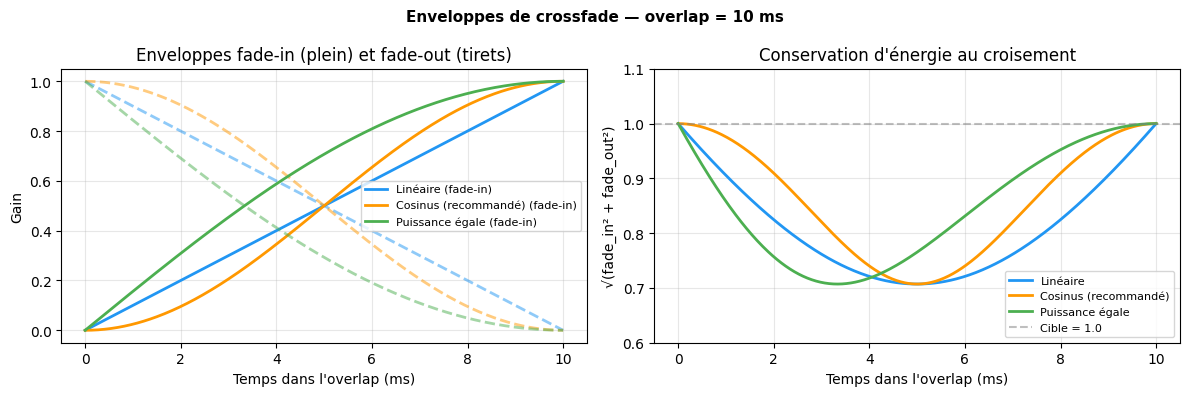

In [7]:
engine.plot_envelopes()